# PT with a toy model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.interpolate import griddata
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

plt.rc('text', usetex=True)
plt.rcParams['text.latex.preamble']=r"\usepackage{amsmath, amssymb}"
plt.rc('font', **{'family' : 'serif', 'size' : 15})


In [2]:
lambda_s  =2*1e-8

vs_zero_T = 4.4*1e8

# allow y to change and see what happens
mDM_0 = 1*vs_zero_T 

mu2       = - lambda_s * vs_zero_T**2

g_s = 106.75 + 1+2*7/8 # symmetric phase

g_b = 106.75 +1 # broken phase

beta1, beta2, beta3 = 8.2983, -5.5330, 0.8180

C_pref = (64.0 * np.sqrt(2.0) * np.pi) / 81.0

def v_s(T, D, xi):
    x = 1.0 - (4*lambda_s*(mu2 + D*T*T)) / (9*xi*xi*T*T)
    if x < 0:
        return np.nan
    return (3*xi*T)/(2*lambda_s)*(1 + np.sqrt(x))

def V_eff(s, T, D, xi):
    return 0.5*(mu2 + D*T*T)*s*s - xi*T*(s**3) + 0.25*lambda_s*(s**4)

def delta_of_T(T, D, xi):
    return (lambda_s/(xi*xi))*(mu2/(T*T) + D)

def DeltaV(T, D, xi):
    s = v_s(T, D, xi)
    if not np.isfinite(s):
        return np.nan
    return V_eff(s, T, D, xi) - V_eff(0.0, T, D, xi)

def dVmin_b_dT(T, D, xi):
    s = v_s(T, D, xi)
    if not np.isfinite(s):
        return np.nan
    return D*T*s*s - xi*s**3

def rho_rad(T, gstar):
    return (np.pi**2 / 30.0) * gstar * T**4

def w_rad(T, gstar):
    return (4.0 * np.pi**2 / 90.0) * gstar * T**4

def alpha_n(D, xi, Tn, gstar_sym=g_s):
    DV = DeltaV(Tn, D, xi)
    dDV = dVmin_b_dT(Tn, D, xi)  # = dDeltaV/dT 
    if not np.isfinite(DV) or not np.isfinite(dDV):
        return np.nan
    return (DV - Tn*dDV) / rho_rad(Tn, gstar_sym)

def Psi_n(D, xi, Tn, gstar_sym=g_s, gstar_bro=g_b):
    dVdT = dVmin_b_dT(Tn, D, xi)
    if not np.isfinite(dVdT):
        return np.nan
    ws = w_rad(Tn, gstar_sym)
    wb = w_rad(Tn, gstar_bro) - Tn * dVdT
    if ws <= 0 or (not np.isfinite(wb)):
        return np.nan
    return wb/ws

def S3_over_T_from_delta(delta, xi):
    # delta in (0,2)
    P = beta1*delta + beta2*delta**2 + beta3*delta**3
    return C_pref * xi / (lambda_s**1.5) * P / (2 - delta)**2

def ddelta_dT(T, xi):
    return -2*lambda_s*mu2 / (xi*xi*T**3)

def dS3T_dT(T, D, xi):
    d = delta_of_T(T, D, xi)
    if (not np.isfinite(d)) or d <= 0 or d >= 2:
        return np.nan
    P  = beta1*d + beta2*d*d + beta3*d*d*d
    Pp = beta1 + 2*beta2*d + 3*beta3*d*d
    u = 2 - d
    dF = 2*P/(u*u*u) + Pp/(u*u)
    return C_pref * xi/(lambda_s**1.5) * dF * ddelta_dT(T, xi)

def beta_over_H(D, xi, Tn):
    deriv = dS3T_dT(Tn, D, xi)
    if not np.isfinite(deriv):
        return np.nan
    return Tn * deriv

# ============================================================
def make_Tgrid(Tmin=1e5, Tmax=1e12, nscan=2500):
    Ts = np.logspace(np.log10(Tmin), np.log10(Tmax), nscan)
    invT2 = 1.0 / (Ts*Ts)
    logT  = np.log(Ts)
    return Ts, invT2, logT

Ts_global, invT2_global, logT_global = make_Tgrid(Tmin=1e5, Tmax=1e16, nscan=2500)

#  141.5 < Sn/T_n < 142.4
def Tn_find_band_fast(D, xi, S_lo=141.5, S_hi=142.4):
    # delta(T) = (lambda/xi^2) * (mu2/T^2 + D)
    delta = (lambda_s/(xi*xi))*(mu2*invT2_global + D)
    ok = np.isfinite(delta) & (delta > 0) & (delta < 2)
    if ok.sum() < 8:
        return np.nan

    d_ok   = delta[ok]
    T_ok   = Ts_global[ok]
    logT_ok = logT_global[ok]

    S_ok = S3_over_T_from_delta(d_ok, xi)
    m = np.isfinite(S_ok)
    if m.sum() < 8:
        return np.nan

    S_ok = S_ok[m]
    T_ok = T_ok[m]
    logT_ok = logT_ok[m]

    S_mid = 0.5*(S_lo + S_hi)
    y = S_ok - S_mid

    idx = np.where(y[:-1]*y[1:] < 0)[0]
    if len(idx) == 0:
        band = (S_ok >= S_lo) & (S_ok <= S_hi)
        if not np.any(band):
            return np.nan
        k = np.argmin(np.abs(S_ok[band] - S_mid))
        return T_ok[band][k]

    i = idx[0]
    x0, x1 = logT_ok[i], logT_ok[i+1]
    y0, y1 = y[i], y[i+1]
    x = x0 - y0*(x1-x0)/(y1-y0)
    Tn = np.exp(x)

    dT = delta_of_T(Tn, D, xi)
    if (not np.isfinite(dT)) or dT <= 0 or dT >= 2:
        return np.nan
    S_Tn = S3_over_T_from_delta(dT, xi)
    if (S_Tn < S_lo) or (S_Tn > S_hi):
        band = (S_ok >= S_lo) & (S_ok <= S_hi)
        if not np.any(band):
            return np.nan
        k = np.argmin(np.abs(S_ok[band] - S_mid))
        return T_ok[band][k]

    return Tn

In [3]:
# ============================================================
# 3) Ai/Laurent/van de Vis LTE wall velocity solver; do not touch!
# ============================================================
def find_vJ(alN, cb2):
    return np.sqrt(cb2) * (1 + np.sqrt(3*alN*(1 - cb2 + 3*cb2*alN))) / (1 + 3*cb2*alN)

def get_vp(vm, al, cb2, branch=-1):
    disc = vm**4 - 2*cb2*vm**2*(1 - 6*al) + cb2**2*(1 - 12*vm**2*al*(1 - 3*al))
    disc = max(disc, 0.0)
    return 0.5*(cb2 + vm**2 + branch*np.sqrt(disc)) / (vm + 3*cb2*vm*al)

def w_from_alpha(alpha, alpha_n, nu, mu):
    return (abs((1 - 3*alpha_n)*mu - nu) + 1e-100) / (abs((1 - 3*alpha)*mu - nu) + 1e-100)

def eqWall(al, alN, vm, nu, mu, psiN, solution=-1):
    vp = get_vp(vm, al, 1/(nu - 1), solution)
    ga2m, ga2p = 1/(1 - vm**2), 1/(1 - vp**2)
    if callable(psiN):
        psi = psiN(vm) * w_from_alpha(al, alN, nu, mu)**(nu/mu - 1)
    else:
        psi = psiN * w_from_alpha(al, alN, nu, mu)**(nu/mu - 1)
    return vp*vm*al/(1 - (nu - 1)*vp*vm) - (1 - 3*al - (ga2p/ga2m)**(nu/2)*psi)/(3*nu)

def solve_alpha(vw, alN, cb2, cs2, psiN):
    nu, mu = 1 + 1/cb2, 1 + 1/cs2
    vm = min(np.sqrt(cb2), vw)
    vp_max = min(cs2/vw, vw)
    al_min = max((vm - vp_max)*(cb2 - vm*vp_max)/(3*cb2*vm*(1 - vp_max**2)), (mu - nu)/(3*mu))
    al_max = 1/3
    branch = -1
    if eqWall(al_min, alN, vm, nu, mu, psiN)*eqWall(al_max, alN, vm, nu, mu, psiN) > 0:
        branch = 1
    sol = root_scalar(eqWall, args=(alN, vm, nu, mu, psiN, branch),
                      bracket=(al_min, al_max), rtol=1e-10, xtol=1e-10, method="brentq")
    return sol.root if sol.converged else np.nan

def dfdv(v, X, cs2):
    xi, w = X
    mu_xiv = (xi - v)/(1 - xi*v)
    dxidv = xi*(1 - v*xi)*(mu_xiv**2/cs2 - 1)
    dxidv /= 2*v*(1 - v**2)
    dwdv = w*(1 + 1/cs2)*mu_xiv/(1 - v**2)
    return [dxidv, dwdv]

def integrate_plasma(v0, vw, w0, c2, shock_wave=True):
    def event(v, X, cs2):
        xi, w = X
        return xi*(xi - v)/(1 - xi*v) - cs2
    event.terminal = True
    if shock_wave:
        sol = solve_ivp(dfdv, (v0, 1e-20), [vw, w0], events=event, args=(c2,),
                        rtol=1e-9, atol=1e-9)
    else:
        sol = solve_ivp(dfdv, (v0, 1e-20), [vw, w0], args=(c2,),
                        rtol=1e-9, atol=1e-9)
    return sol

def shooting(vw, alN, cb2, cs2, psiN):
    nu, mu = 1 + 1/cb2, 1 + 1/cs2
    vm = min(np.sqrt(cb2), vw)
    al = solve_alpha(vw, alN, cb2, cs2, psiN)
    if not np.isfinite(al):
        return np.nan
    vp = get_vp(vm, al, cb2)
    wp = w_from_alpha(al, alN, nu, mu)
    sol = integrate_plasma((vw - vp)/(1 - vw*vp), vw, wp, cs2)
    if not sol.success:
        return np.nan
    vp_sw = sol.y[0, -1]
    vm_sw = (vp_sw - sol.t[-1])/(1 - vp_sw*sol.t[-1])
    wm_sw = sol.y[1, -1]
    return vp_sw/vm_sw - ((mu - 1)*wm_sw + 1)/((mu - 1) + wm_sw)

def max_al(cb2, cs2, psiN, upper_limit=100):
    nu, mu = 1 + 1/cb2, 1 + 1/cs2
    vm = np.sqrt(cb2)
    effectivePsi = psiN(vm) if callable(psiN) else psiN
    def func(alN):
        vw = find_vJ(alN, cb2)
        vp = cs2/vw
        ga2p, ga2m = 1/(1 - vp**2), 1/(1 - vm**2)
        wp = (vp + vw - vw*mu)/(vp + vw - vp*mu)
        psi = effectivePsi * wp**(nu/mu - 1)
        al = (mu - nu)/(3*mu) + (alN - (mu - nu)/(3*mu))/wp
        return vp*vm*al/(1 - (nu - 1)*vp*vm) - (1 - 3*al - (ga2p/ga2m)**(nu/2)*psi)/(3*nu)
    if func(upper_limit) < 0:
        return upper_limit
    lower_limit = (1 - effectivePsi)/3
    sol = root_scalar(func, bracket=(lower_limit, upper_limit), rtol=1e-10, xtol=1e-10, method="brentq")
    return sol.root if sol.converged else np.nan

def shooting2(vw, vp, wp, cs2):
    mu = 1 + 1/cs2
    sol = integrate_plasma((vw - vp)/(1 - vw*vp), vw, wp, cs2)
    if not sol.success:
        return np.nan
    vp_sw = sol.y[0, -1]
    vm_sw = (vp_sw - sol.t[-1])/(1 - vp_sw*sol.t[-1])
    wm_sw = sol.y[1, -1]
    return vp_sw/vm_sw - ((mu - 1)*wm_sw + 1)/((mu - 1) + wm_sw)

def min_vw(alN, cb2, cs2):
    nu, mu = 1 + 1/cb2, 1 + 1/cs2
    vp = 0.0
    wp = w_from_alpha(1/3, alN, nu, mu)
    f0 = shooting2(1e-4, vp, wp, cs2)
    if not np.isfinite(f0):
        return 1e-4
    if f0 > 0:
        return 1e-4
    sol = root_scalar(shooting2, args=(vp, wp, cs2),
                      bracket=[1e-4, find_vJ(alN, cb2)], method="brentq")
    return sol.root if sol.converged else 1e-4

def find_vw(alN, cb2, cs2, psiN):
    nu, mu = 1 + 1/cb2, 1 + 1/cs2
    vJ = find_vJ(alN, cb2)
    effectivePsi = psiN(0) if callable(psiN) else psiN
    if alN < (1 - effectivePsi)/3 or alN <= (mu - nu)/(3*mu):
        return 0.0
    shot_vJ = shooting(vJ, alN, cb2, cs2, psiN)
    if (not np.isfinite(shot_vJ)) or (alN > max_al(cb2, cs2, psiN, 100)) or (shot_vJ < 0):
        return 1.0
    vmin = min_vw(alN, cb2, cs2)
    if vmin >= vJ:
        return min(1.0, vJ)
    sol = root_scalar(shooting, args=(alN, cb2, cs2, psiN),
                      bracket=[vmin, vJ], rtol=1e-9, xtol=1e-9, method="brentq")
    return sol.root if sol.converged else np.nan

In [4]:
Psi_n(1.36*1e-9, 4.92*1e-7, 2.59*1e11, gstar_sym=g_s, gstar_bro=g_b)

np.float64(0.9881351647456655)

# $v_w$ scan in the toy model

In [5]:
# ============================================================
# 4) Scan your model and compute vw(D, xi)
# ============================================================

# ---------- scan ranges ----------
cb2 = 1/3
cs2 = 1/3

Nxi = 120
ND  = 120

# Broad log scan around your previous viable region
xi_vals = np.logspace(np.log10(1e-7), np.log10(1e-5), Nxi)
D_vals  = np.logspace(np.log10(1e-10), np.log10(1e-8), ND)

S_LO, S_HI = 141.5, 142.4

# If needed, redefine the global temperature grid before scan
Ts_global, invT2_global, logT_global = make_Tgrid(
    Tmin=1e4,
    Tmax=1e16,
    nscan=6000
)

# ---------- storage arrays ----------
Tn_grid    = np.full((Nxi, ND), np.nan)
alpha_grid = np.full((Nxi, ND), np.nan)
Psi_grid   = np.full((Nxi, ND), np.nan)
betaH_grid = np.full((Nxi, ND), np.nan)
vw_grid    = np.full((Nxi, ND), np.nan)

status_grid = np.full((Nxi, ND), -1, dtype=int)

# status:
# -1 : not evaluated / invalid
#  0 : no nucleation or no physical solution -> vw = 0
#  1 : finite LTE wall velocity
#  2 : runaway / no static LTE solution -> vw = 1


def safe_find_vw(alN, psiN, cb2=1/3, cs2=1/3):
    if (not np.isfinite(alN)) or (not np.isfinite(psiN)):
        return 0.0, 0

    if alN <= 0 or psiN <= 0:
        return 0.0, 0

    try:
        vw = find_vw(alN, cb2, cs2, psiN)
    except Exception:
        return 0.0, 0

    if not np.isfinite(vw):
        return 0.0, 0

    if vw < 0:
        return 0.0, 0

    if vw > 1:
        return 1.0, 2

    if np.isclose(vw, 1.0, rtol=0.0, atol=1e-8):
        return 1.0, 2

    return float(vw), 1


# ---------- main scan ----------
for i, xi in enumerate(xi_vals):
    for j, D in enumerate(D_vals):

        Tn = Tn_find_band_fast(D, xi, S_lo=S_LO, S_hi=S_HI)

        if not np.isfinite(Tn):
            vw_grid[i, j] = 0.0
            status_grid[i, j] = 0
            continue

        alN = alpha_n(D, xi, Tn)
        psN = Psi_n(D, xi, Tn)
        bH  = beta_over_H(D, xi, Tn)

        vw, status = safe_find_vw(alN, psN, cb2=cb2, cs2=cs2)

        Tn_grid[i, j]    = Tn
        alpha_grid[i, j] = alN
        Psi_grid[i, j]   = psN
        betaH_grid[i, j] = bH
        vw_grid[i, j]    = vw
        status_grid[i, j] = status


print("valid nucleation points:", np.sum(np.isfinite(Tn_grid)))
print("finite LTE vw:", np.sum(status_grid == 1))
print("runaway / no static LTE solution:", np.sum(status_grid == 2))
print("no nucleation / no solution:", np.sum(status_grid == 0))

print("alpha range:",
      np.nanmin(alpha_grid), np.nanmax(alpha_grid))

print("Psi range:",
      np.nanmin(Psi_grid), np.nanmax(Psi_grid))

print("vw range:",
      np.nanmin(vw_grid), np.nanmax(vw_grid))

/tmp/ipykernel_6914/2144948423.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  dxidv /= 2*v*(1 - v**2)
/tmp/ipykernel_6914/2144948423.py:39: RuntimeWarning: invalid value encountered in scalar multiply
  mu_xiv = (xi - v)/(1 - xi*v)
/tmp/ipykernel_6914/2144948423.py:40: RuntimeWarning: invalid value encountered in scalar multiply
  dxidv = xi*(1 - v*xi)*(mu_xiv**2/cs2 - 1)


valid nucleation points: 4371
finite LTE vw: 3096
runaway / no static LTE solution: 50
no nucleation / no solution: 11254
alpha range: 6.963243044499645e-06 10.755033000972697
Psi range: 0.9840252432654426 11.73905185372419
vw range: 0.0 1.0


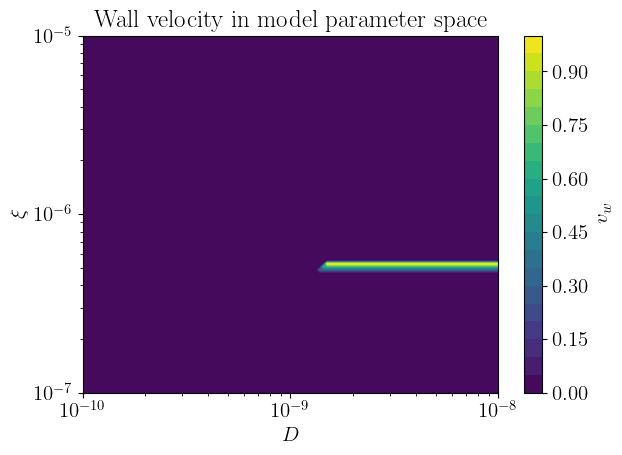

In [6]:
# ============================================================
# 5) Plot vw in the original model plane (D, xi)
# ============================================================

D_mesh, xi_mesh = np.meshgrid(D_vals, xi_vals)

fig, ax = plt.subplots(figsize=(6.5, 4.8))

cf = ax.contourf(
    D_mesh,
    xi_mesh,
    vw_grid,
    levels=np.linspace(0.0, 1.0, 21),
    cmap="viridis",
    vmin=0.0,
    vmax=1.0
)

ax.set_xscale("log")
ax.set_yscale("log")

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$D$")
ax.set_ylabel(r"$\xi$")
ax.set_title(r"Wall velocity in model parameter space")

plt.tight_layout()
plt.savefig("vw_D_xi_logscan.pdf", bbox_inches="tight")
plt.savefig("vw_D_xi_logscan.png", dpi=300, bbox_inches="tight")
plt.show()

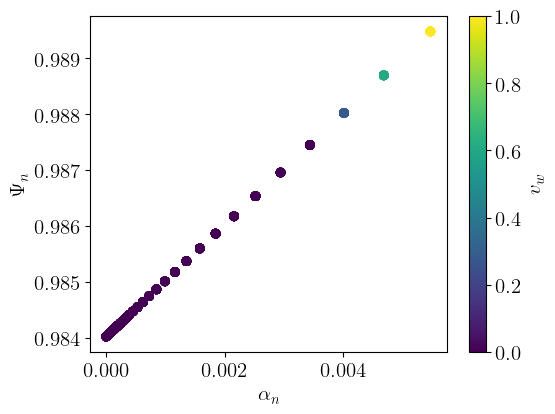

In [7]:
mask_good = (
    np.isfinite(alpha_grid)
    & np.isfinite(Psi_grid)
    & np.isfinite(vw_grid)
    & (status_grid > 0)
)

fig, ax = plt.subplots(figsize=(5.8, 4.4))

sc = ax.scatter(
    alpha_grid[mask_good],
    Psi_grid[mask_good],
    c=vw_grid[mask_good],
    s=35,
    cmap="viridis",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")

plt.tight_layout()
plt.show()

In [8]:
print("finite points =", np.sum(status_grid == 1))
print("runaway points =", np.sum(status_grid == 2))
print("no solution points =", np.sum(status_grid == 0))

print("alpha range good =",
      np.nanmin(alpha_grid[mask_good]),
      np.nanmax(alpha_grid[mask_good]))

print("Psi range good =",
      np.nanmin(Psi_grid[mask_good]),
      np.nanmax(Psi_grid[mask_good]))

finite points = 3096
runaway points = 50
no solution points = 11254
alpha range good = 6.963243044499645e-06 0.005463461328663397
Psi range good = 0.9840252432654426 0.989481728160085


In [9]:
# ============================================================
# Find where nonzero / physical vw points come from in (D, xi)
# ============================================================

D_mesh, xi_mesh = np.meshgrid(D_vals, xi_vals)

mask_good = (
    np.isfinite(Tn_grid)
    & np.isfinite(alpha_grid)
    & np.isfinite(Psi_grid)
    & np.isfinite(vw_grid)
    & (vw_grid > 1e-3)
)

print("good points =", np.sum(mask_good))

print("D good range:")
print(np.nanmin(D_mesh[mask_good]), np.nanmax(D_mesh[mask_good]))

print("xi good range:")
print(np.nanmin(xi_mesh[mask_good]), np.nanmax(xi_mesh[mask_good]))

print("alpha good range:")
print(np.nanmin(alpha_grid[mask_good]), np.nanmax(alpha_grid[mask_good]))

print("Psi good range:")
print(np.nanmin(Psi_grid[mask_good]), np.nanmax(Psi_grid[mask_good]))

print("vw good range:")
print(np.nanmin(vw_grid[mask_good]), np.nanmax(vw_grid[mask_good]))

good points = 153
D good range:
1.389495494373136e-09 1e-08
xi good range:
4.887374631624427e-07 5.280670574582637e-07
alpha good range:
0.004007489748888803 0.005463461328663397
Psi good range:
0.9880260773083506 0.989481728160085
vw good range:
0.27669815079562504 1.0


In [10]:
# ============================================================
# Auto-zoom scan range around nonzero vw points
# ============================================================

D_good  = D_mesh[mask_good]
xi_good = xi_mesh[mask_good]

margin = 2.0

D_min_new  = np.nanmin(D_good)  / margin
D_max_new  = np.nanmax(D_good)  * margin
xi_min_new = np.nanmin(xi_good) / margin
xi_max_new = np.nanmax(xi_good) * margin

print("new D range =", D_min_new, D_max_new)
print("new xi range =", xi_min_new, xi_max_new)

Nxi = 180
ND  = 180

D_vals  = np.logspace(np.log10(D_min_new),  np.log10(D_max_new),  ND)
xi_vals = np.logspace(np.log10(xi_min_new), np.log10(xi_max_new), Nxi)

new D range = 6.94747747186568e-10 2e-08
new xi range = 2.4436873158122137e-07 1.0561341149165274e-06


In [11]:

cb2 = 1/3
cs2 = 1/3

# Nxi = 120
# ND  = 120

# # Broad log scan around your previous viable region
# xi_vals = np.logspace(np.log10(1e-7), np.log10(1e-5), Nxi)
# D_vals  = np.logspace(np.log10(1e-10), np.log10(1e-8), ND)

S_LO, S_HI = 141.5, 142.4

# If needed, redefine the global temperature grid before scan
Ts_global, invT2_global, logT_global = make_Tgrid(
    Tmin=1e4,
    Tmax=1e16,
    nscan=6000
)

# ---------- storage arrays ----------
Tn_grid    = np.full((Nxi, ND), np.nan)
alpha_grid = np.full((Nxi, ND), np.nan)
Psi_grid   = np.full((Nxi, ND), np.nan)
betaH_grid = np.full((Nxi, ND), np.nan)
vw_grid    = np.full((Nxi, ND), np.nan)

status_grid = np.full((Nxi, ND), -1, dtype=int)

# status:
# -1 : not evaluated / invalid
#  0 : no nucleation or no physical solution -> vw = 0
#  1 : finite LTE wall velocity
#  2 : runaway / no static LTE solution -> vw = 1


def safe_find_vw(alN, psiN, cb2=1/3, cs2=1/3):
    if (not np.isfinite(alN)) or (not np.isfinite(psiN)):
        return 0.0, 0

    if alN <= 0 or psiN <= 0:
        return 0.0, 0

    try:
        vw = find_vw(alN, cb2, cs2, psiN)
    except Exception:
        return 0.0, 0

    if not np.isfinite(vw):
        return 0.0, 0

    if vw < 0:
        return 0.0, 0

    if vw > 1:
        return 1.0, 2

    if np.isclose(vw, 1.0, rtol=0.0, atol=1e-8):
        return 1.0, 2

    return float(vw), 1


# ---------- main scan ----------
for i, xi in enumerate(xi_vals):
    for j, D in enumerate(D_vals):

        Tn = Tn_find_band_fast(D, xi, S_lo=S_LO, S_hi=S_HI)

        if not np.isfinite(Tn):
            vw_grid[i, j] = 0.0
            status_grid[i, j] = 0
            continue

        alN = alpha_n(D, xi, Tn)
        psN = Psi_n(D, xi, Tn)
        bH  = beta_over_H(D, xi, Tn)

        vw, status = safe_find_vw(alN, psN, cb2=cb2, cs2=cs2)

        Tn_grid[i, j]    = Tn
        alpha_grid[i, j] = alN
        Psi_grid[i, j]   = psN
        betaH_grid[i, j] = bH
        vw_grid[i, j]    = vw
        status_grid[i, j] = status


print("valid nucleation points:", np.sum(np.isfinite(Tn_grid)))
print("finite LTE vw:", np.sum(status_grid == 1))
print("runaway / no static LTE solution:", np.sum(status_grid == 2))
print("no nucleation / no solution:", np.sum(status_grid == 0))

print("alpha range:",
      np.nanmin(alpha_grid), np.nanmax(alpha_grid))

print("Psi range:",
      np.nanmin(Psi_grid), np.nanmax(Psi_grid))

print("vw range:",
      np.nanmin(vw_grid), np.nanmax(vw_grid))

/tmp/ipykernel_6914/2144948423.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  dxidv /= 2*v*(1 - v**2)
/tmp/ipykernel_6914/2144948423.py:39: RuntimeWarning: invalid value encountered in scalar multiply
  mu_xiv = (xi - v)/(1 - xi*v)
/tmp/ipykernel_6914/2144948423.py:40: RuntimeWarning: invalid value encountered in scalar multiply
  dxidv = xi*(1 - v*xi)*(mu_xiv**2/cs2 - 1)


valid nucleation points: 25617
finite LTE vw: 14856
runaway / no static LTE solution: 422
no nucleation / no solution: 17122
alpha range: 0.0002498091549266355 0.08741852513273302
Psi range: 0.984268254193261 1.0714367963828788
vw range: 0.0 1.0


finite branch boundary points:

left / lower-alpha boundary:
alpha = 0.004036606234537752
Psi   = 0.9880555693173538
vw    = 0.440232353609738

right / upper-alpha boundary:
alpha = 0.004915280349482731
Psi   = 0.98893354519599
vw    = 0.6247553230334786


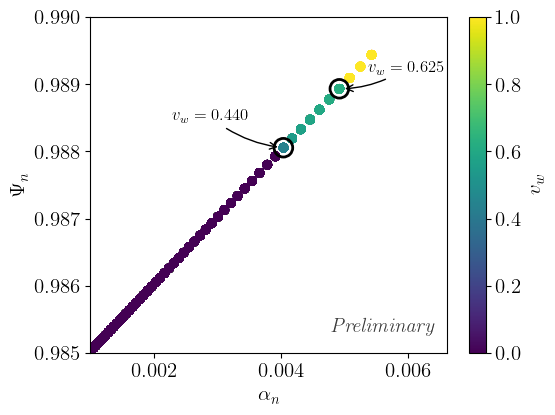

In [12]:
# ============================================================
# Plot all scan points
# ============================================================

mask_plot = (
    np.isfinite(alpha_grid)
    & np.isfinite(Psi_grid)
    & np.isfinite(vw_grid)
    & (status_grid > 0)
)

fig, ax = plt.subplots(figsize=(5.8, 4.4))

sc = ax.scatter(
    alpha_grid[mask_plot],
    Psi_grid[mask_plot],
    c=vw_grid[mask_plot],
    s=35,
    cmap="viridis",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")

# Preliminary label
ax.text(
    0.97, 0.05,
    r"\textit{Preliminary}",
    transform=ax.transAxes,
    fontsize=15,
    ha="right",
    va="bottom",
    alpha=0.75
)


# ============================================================
# Finite branch: 0 < vw < 1
# ============================================================

mask_branch = (
    np.isfinite(alpha_grid)
    & np.isfinite(Psi_grid)
    & np.isfinite(vw_grid)
    & (vw_grid > 1e-6)       # remove vw = 0
    & (vw_grid < 1 - 1e-6)   # remove runaway vw = 1
)

xb = alpha_grid[mask_branch]
yb = Psi_grid[mask_branch]
vb = vw_grid[mask_branch]

if len(vb) > 0:

    k_left  = np.argmin(xb)
    k_right = np.argmax(xb)

    xL, yL, vL = xb[k_left],  yb[k_left],  vb[k_left]
    xR, yR, vR = xb[k_right], yb[k_right], vb[k_right]

    ax.scatter(
        [xL, xR],
        [yL, yR],
        s=180,
        facecolors="none",
        edgecolors="black",
        linewidths=2.0,
        zorder=10
    )

    ax.annotate(
        rf"$v_w={vL:.3f}$",
        xy=(xL, yL),
        xytext=(xL - 0.00055, yL + 0.00035),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.0,
            color="black",
            shrinkA=2,
            shrinkB=4,
            connectionstyle="arc3,rad=0.15"
        ),
        fontsize=12,
        color="black",
        ha="right",
        va="bottom",
        zorder=11
    )

    ax.annotate(
        rf"$v_w={vR:.3f}$",
        xy=(xR, yR),
        xytext=(xR + 0.00045, yR + 0.0002),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.0,
            color="black",
            shrinkA=2,
            shrinkB=4,
            connectionstyle="arc3,rad=-0.15"
        ),
        fontsize=12,
        color="black",
        ha="left",
        va="bottom",
        zorder=11
    )

    print("finite branch boundary points:")
    print()
    print("left / lower-alpha boundary:")
    print("alpha =", xL)
    print("Psi   =", yL)
    print("vw    =", vL)
    print()
    print("right / upper-alpha boundary:")
    print("alpha =", xR)
    print("Psi   =", yR)
    print("vw    =", vR)

else:
    print("No finite branch with 0 < vw < 1 found.")


# ============================================================
# Control x/y plot range
# ============================================================

ax.set_xlim(0.001, 0.0066)
ax.set_ylim(0.985, 0.99)

plt.tight_layout()
plt.show()

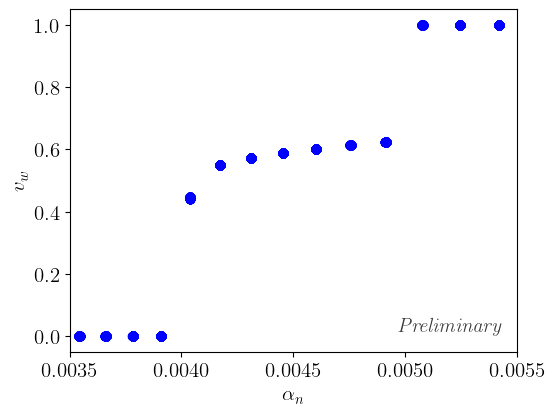

In [13]:
mask_plot = (
    np.isfinite(alpha_grid)
    & np.isfinite(vw_grid)
    & (status_grid > 0)
)

x = alpha_grid[mask_plot]
y = vw_grid[mask_plot]

# sort by alpha_n before connecting
order = np.argsort(x)
x = x[order]
y = y[order]

fig, ax = plt.subplots(figsize=(5.8, 4.4))

ax.plot(
    x,
    y,
    "o",
    color="blue",
    markersize=6,
    linewidth=1.2
)

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$v_w$")

ax.text(
    0.97, 0.05,
    r"\textit{Preliminary}",
    transform=ax.transAxes,
    fontsize=15,
    ha="right",
    va="bottom",
    alpha=0.75
)

ax.set_xlim(0.0035, 0.0055)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

# $v_w$ on the $(\alpha_n,\Psi_n)$ grid

In [14]:
# ============================================================
# Direct hydrodynamic grid: v_w(alpha_n, Psi_n)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Settings
# ------------------------------------------------------------

cb2 = 1/3
cs2 = 1/3

# alpha region
alpha_min = 0.0005
alpha_max = 0.0090
# Psi region
Psi_min = 0.9845
Psi_max = 1

Nalpha = 100
NPsi   = 100

alpha_vals = np.linspace(alpha_min, alpha_max, Nalpha)
Psi_vals   = np.linspace(Psi_min, Psi_max, NPsi)

A_mesh, P_mesh = np.meshgrid(alpha_vals, Psi_vals)

vw_AP_grid = np.full_like(A_mesh, np.nan, dtype=float)
status_AP_grid = np.full_like(A_mesh, -1, dtype=int)


# ------------------------------------------------------------
# 2) Safe wrapper for find_vw
# ------------------------------------------------------------

def safe_find_vw_AP(alN, psiN, cb2=1/3, cs2=1/3):
    """
    Classification used here:

    status = 0 : vw = 0 or no physical output
    status = 1 : 0 < vw < 1
    status = 2 : vw = 1, runaway / no static LTE solution
    """

    if (not np.isfinite(alN)) or (not np.isfinite(psiN)):
        return 0.0, 0

    if alN <= 0 or psiN <= 0:
        return 0.0, 0

    try:
        vw = find_vw(alN, cb2, cs2, psiN)
    except Exception:
        return 0.0, 0

    if not np.isfinite(vw):
        return 0.0, 0

    if vw <= 1e-8:
        return 0.0, 0

    if vw >= 1.0 - 1e-8:
        return 1.0, 2

    return float(vw), 1


# ------------------------------------------------------------
# 3) Compute v_w directly on the alpha-Psi grid
# ------------------------------------------------------------

for i in range(NPsi):
    for j in range(Nalpha):

        alN = A_mesh[i, j]
        psN = P_mesh[i, j]

        vw, status = safe_find_vw_AP(alN, psN, cb2=cb2, cs2=cs2)

        vw_AP_grid[i, j] = vw
        status_AP_grid[i, j] = status


print("alpha-Psi hydrodynamic grid computed")
print("status = 0 points:", np.sum(status_AP_grid == 0))
print("status = 1 points:", np.sum(status_AP_grid == 1))
print("status = 2 points:", np.sum(status_AP_grid == 2))
print("vw range:", np.nanmin(vw_AP_grid), np.nanmax(vw_AP_grid))

/tmp/ipykernel_6914/2144948423.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  dxidv /= 2*v*(1 - v**2)
/tmp/ipykernel_6914/2144948423.py:39: RuntimeWarning: invalid value encountered in scalar multiply
  mu_xiv = (xi - v)/(1 - xi*v)
/tmp/ipykernel_6914/2144948423.py:40: RuntimeWarning: invalid value encountered in scalar multiply
  dxidv = xi*(1 - v*xi)*(mu_xiv**2/cs2 - 1)


alpha-Psi hydrodynamic grid computed
status = 0 points: 8343
status = 1 points: 1060
status = 2 points: 597
vw range: 0.0 1.0


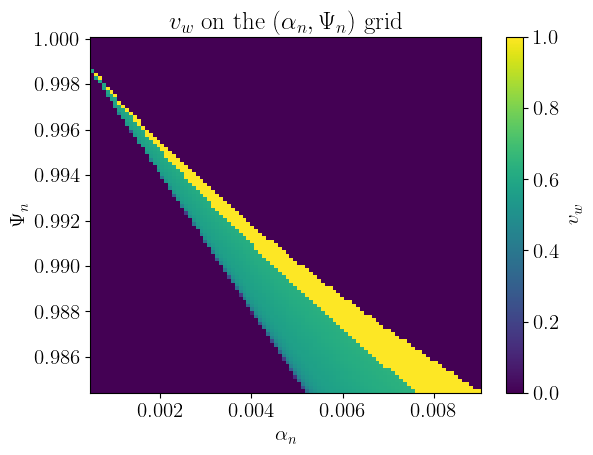

In [34]:

fig, ax = plt.subplots(figsize=(6.2, 4.8))

pcm = ax.pcolormesh(
    A_mesh,
    P_mesh,
    vw_AP_grid,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")
ax.set_title(r"$v_w$ on the $(\alpha_n,\Psi_n)$ grid")

# ax.text(
#     0.97, 0.05, r"\textit{Preliminary}",
#     transform=ax.transAxes,
#     fontsize=15,
#     ha="right",
#     va="bottom",
#     alpha=0.75
# )

plt.tight_layout()
plt.show()


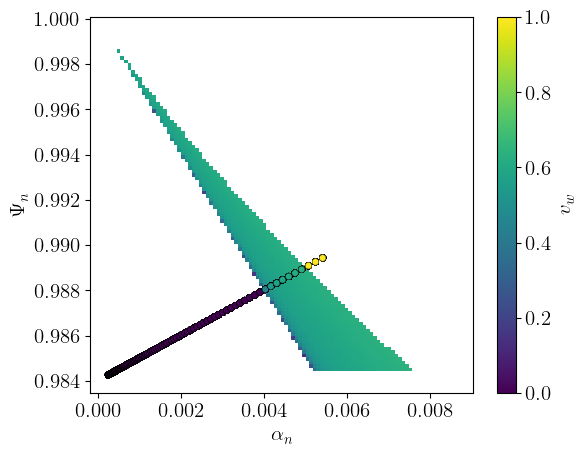

In [35]:

vw_finite_only = np.where(status_AP_grid == 1, vw_AP_grid, np.nan)

fig, ax = plt.subplots(figsize=(6.2, 4.8))

pcm = ax.pcolormesh(
    A_mesh,
    P_mesh,
    vw_finite_only,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$v_w$")

ax.scatter(
    alpha_grid[mask_model],
    Psi_grid[mask_model],
    c=vw_grid[mask_model],
    s=22,
    cmap="viridis",
    vmin=0,
    vmax=1,
    edgecolors="black",
    linewidths=0.25,
    # label="model scan"
)

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")
# ax.set_title(r"Physical finite-wall region and model trajectory")


plt.tight_layout()
plt.show()

# export data

In [30]:
import pandas as pd
import numpy as np

# ============================================================
# Save only status = 1 points, with only three columns
# alpha_n, Psi_n, v_w
# ============================================================

mask_status1 = (status_AP_grid == 1)

df_status1 = pd.DataFrame({
    "alpha_n": A_mesh[mask_status1].ravel(),
    "Psi_n": P_mesh[mask_status1].ravel(),
    "v_w": vw_AP_grid[mask_status1].ravel()
})

df_status1.to_csv("vw_alpha_Psi.csv", index=False)

print("Saved: vw_alpha_Psi.csv")
print("number of rows =", len(df_status1))
print(df_status1.head())

Saved: vw_alpha_Psi.csv
number of rows = 1060
    alpha_n   Psi_n       v_w
0  0.005222  0.9845  0.375827
1  0.005308  0.9845  0.483678
2  0.005394  0.9845  0.520602
3  0.005480  0.9845  0.539855
4  0.005566  0.9845  0.552120


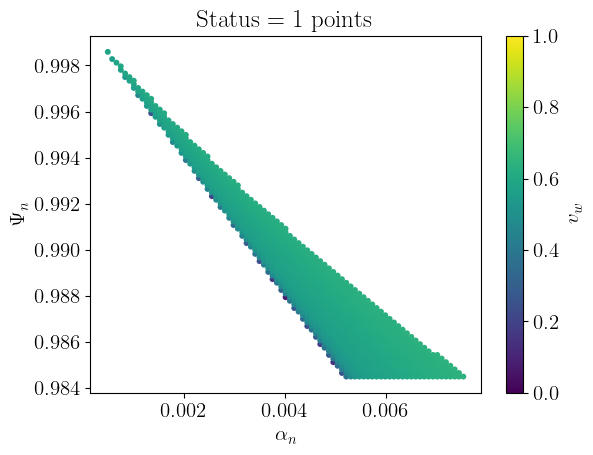

In [31]:
df = pd.read_csv("vw_alpha_Psi.csv")

fig, ax = plt.subplots(figsize=(6.2, 4.8))

sc = ax.scatter(
    df["alpha_n"],
    df["Psi_n"],
    c=df["v_w"],
    s=18,
    cmap="viridis",
    vmin=0,
    vmax=1,
    edgecolors="none"
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")
ax.set_title(r"Status = 1 points")

plt.tight_layout()
plt.show()

In [32]:

# ============================================================
# Save the full uniform alpha-Psi grid used by pcolormesh
# Columns: alpha_n, Psi_n, v_w
# ============================================================

df_grid = pd.DataFrame({
    "alpha_n": A_mesh.ravel(),
    "Psi_n": P_mesh.ravel(),
    "v_w": vw_AP_grid.ravel()
})

df_grid.to_csv("vw_alpha_Psi_uniform_grid.csv", index=False)

print("Saved: vw_alpha_Psi_uniform_grid.csv")
print("rows =", len(df_grid))
print(df_grid.head())

Saved: vw_alpha_Psi_uniform_grid.csv
rows = 10000
    alpha_n   Psi_n  v_w
0  0.000500  0.9845  0.0
1  0.000586  0.9845  0.0
2  0.000672  0.9845  0.0
3  0.000758  0.9845  0.0
4  0.000843  0.9845  0.0


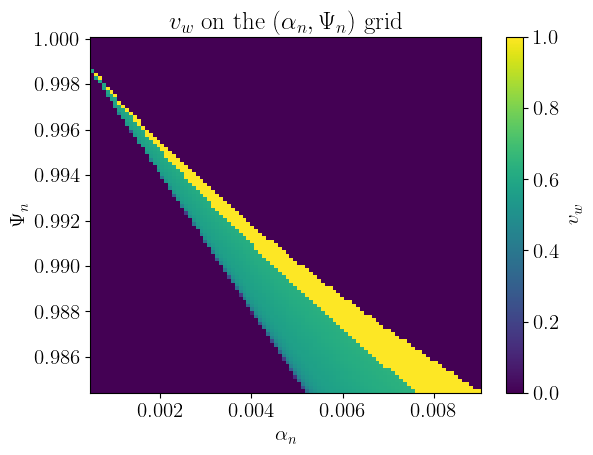

In [33]:
# ============================================================
# Read full uniform alpha-Psi grid CSV and plot
# ============================================================

df = pd.read_csv("vw_alpha_Psi_uniform_grid.csv")

# Extract sorted unique grid values
alpha_vals = np.sort(df["alpha_n"].unique())
Psi_vals   = np.sort(df["Psi_n"].unique())

# Reconstruct 2D mesh
A_mesh, P_mesh = np.meshgrid(alpha_vals, Psi_vals)

# Reconstruct v_w grid
vw_grid_plot = df.pivot(
    index="Psi_n",
    columns="alpha_n",
    values="v_w"
).values

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(6.2, 4.8))

pcm = ax.pcolormesh(
    A_mesh,
    P_mesh,
    vw_grid_plot,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=1
)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$v_w$")

ax.set_xlabel(r"$\alpha_n$")
ax.set_ylabel(r"$\Psi_n$")
ax.set_title(r"$v_w$ on the $(\alpha_n,\Psi_n)$ grid")

plt.tight_layout()
plt.show()